# Analytical Velocity

$\
W_{\mathrm{c}} = \frac{2.07 \cdot Ek_c}{R_1} \cdot \mathrm{e}^{\,2.3026 \frac{x}{R_1}}
\
$

$
\text{AV}= Ek_{\text{pump}} + W_c
$

where $AV$ is in $ms^{-1}$ , $e$ is the Euler number and $x$ is the distance to the coast. 

* Wc is computed from the cross-shore Ekman transport evaluated at the coastline, and distributed offshore following an exponential decay over the first baroclinic Rossby radius $R_1$, such that $w_c$ reaches 10% of its coastal value at $x=R_1$ (Bordbar et al. 2021; Fennel 1999).
* Is important to take into consideration that in Boardbar paper, the coastal angle for Benguela is close to $0^{\circ}$ with the North, for which the rotation done is not needed there, and we will use the Uekman non rotated but geographical transport for building this index. However when the rotation is effective the Analytical velocity wouldn't work for the Peruvian Sea which angle is $45^{\circ}$

In [1]:
import xarray as xr
from scipy.ndimage import binary_erosion, binary_dilation
import math
import numpy as np

## Functions

In [2]:
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Data

In [4]:
lati1,lati2=-5,-16

In [5]:
R_X = xr.open_dataset('Rossby_radius_and_X.nc').compute()
mask = coastal_band_mask(R_X, var='R', iterations=10)

In [6]:
R_X = R_X.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1)) 
R_X

<xarray.Dataset> Size: 419kB
Dimensions:  (lat: 134, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    R        (lat, lon) float64 208kB nan nan nan nan nan ... nan nan nan nan
    X        (lat, lon) float64 208kB nan nan nan nan nan ... nan nan nan nan

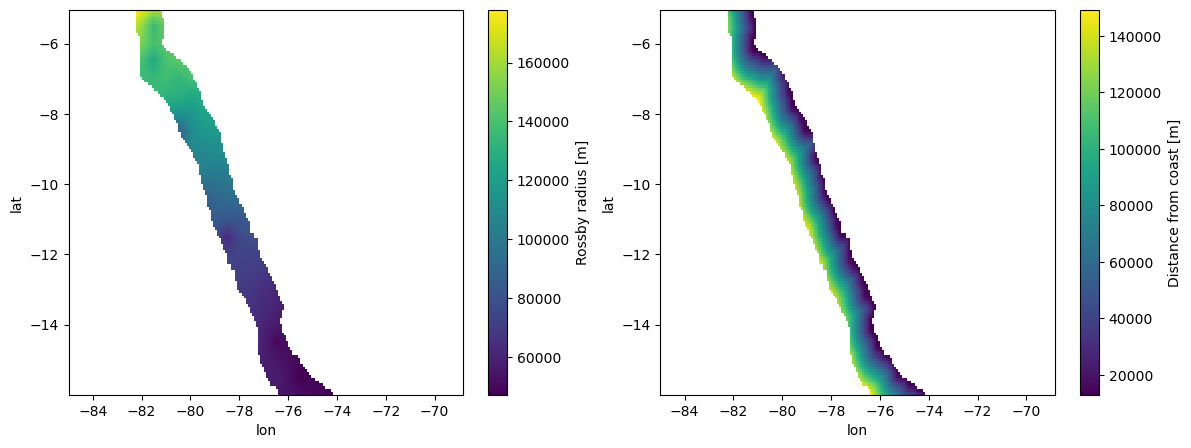

In [7]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,2,figsize=(14,5))
R_X.R.plot(ax=ax[0])
R_X.X.plot(ax=ax[1])

In [8]:
#### Inshore
valid = xr.where(np.isfinite(R_X.R), 1, 0)
valid_w = valid.shift(lon=-1) #west
# Boolean mask of valid ocean cells
valid_in = xr.where(np.isfinite(R_X.R), 1, 0)
# valid_e = valid.shift(lon=+1)  # east

inshore_mask = (valid_in == 1) & (valid_w == 0)

R_inshore = R_X.R.where(inshore_mask)

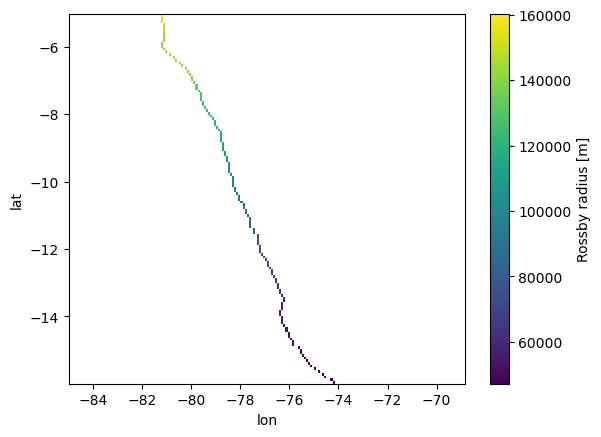

In [9]:
R_inshore.plot()

In [10]:
winds_c = xr.open_dataset('latitudinal/Winds_components_Lu.nc').compute()
winds_c

<xarray.Dataset> Size: 46MB
Dimensions:          (time: 432, coast_point: 221, offshore: 10)
Coordinates:
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
  * coast_point      (coast_point) int64 2kB 0 1 2 3 4 5 ... 216 217 218 219 220
  * offshore         (offshore) int64 80B 0 1 2 3 4 5 6 7 8 9
    lat              (coast_point, offshore) float64 18kB -19.99 ... -2.082
    lon              (coast_point, offshore) float64 18kB -71.03 ... -80.95
    bearing          (coast_point) float64 2kB 90.0 90.0 90.0 ... 45.0 90.0 90.0
    distance         (coast_point, offshore) float64 18kB 8.708e+04 ... 9.26e+03
    f                (coast_point, offshore) float64 18kB -4.987e-05 ... -5.2...
Data variables:
    wind_alongshore  (time, coast_point, offshore) float64 8MB 3.89 ... 4.206
    tau_alongshore   (time, coast_point, offshore) float64 8MB 0.02406 ... 0....
    etransport       (time, coast_point, offshore) float64 8MB 5.406e-06 ... ...
    epumping         (time, coast_point, offshore) float64 8MB -1.341e-06 ......
    Ek_layer_D       (time, coast_point, offshore) float64 8MB 28.68 ... 113.2
    U_ek_cross       (time, coast_point, offshore) float64 8MB 0.4708 ... 6.161
Attributes:
    description:  Alongshore winds, Ekman transport and pumping (NHUS, 5°S–16°S)

In [11]:
Uek_inshore = (winds_c.U_ek_cross
        .isel(offshore=0)
        .swap_dims({'coast_point': 'lat'})
        .drop_vars(['coast_point', 'lon', 'bearing', 'distance', 'f', 'offshore']))
Uek_inshore

<xarray.DataArray 'U_ek_cross' (time: 432, lat: 221)> Size: 764kB
array([[0.47077047, 0.46868903, 0.46739847, ..., 5.60168058, 5.43658235,
        5.56174778],
       [0.50015188, 0.50011023, 0.50099314, ..., 3.21576567, 2.88127034,
        2.89439867],
       [0.52221533, 0.51689966, 0.51244225, ..., 1.60692423, 1.4340936 ,
        1.44019013],
       ...,
       [0.70361879, 0.69442059, 0.68506383, ..., 9.33127552, 9.2368636 ,
        9.4412787 ],
       [0.6886988 , 0.68435476, 0.68065091, ..., 9.83410705, 9.498648  ,
        9.70110201],
       [0.62637977, 0.6249985 , 0.62453954, ..., 7.71256828, 7.68518914,
        7.82504339]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -2.249 -2.166 -2.082
Attributes:
    units:      m^2/s
    long_name:  Cross-shore Ekman transport (BUI)

In [12]:
# R_X = R_X.mean(dim=('lon'))
R_X

<xarray.Dataset> Size: 419kB
Dimensions:  (lat: 134, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    R        (lat, lon) float64 208kB nan nan nan nan nan ... nan nan nan nan
    X        (lat, lon) float64 208kB nan nan nan nan nan ... nan nan nan nan

In [13]:
e =math.e
# r= R_inshore.mean('lon')
r=R_X.R
x= R_X.X
Uek = Uek_inshore

# print(e.shape)
print(r.shape)
print(x.shape)
print(Uek.shape)

(134, 194)
(134, 194)
(432, 221)


In [14]:
Wc = ((2.07 * Uek)/r)*e**(-2.3026*x/r)
Wc #already in m/s

<xarray.DataArray (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

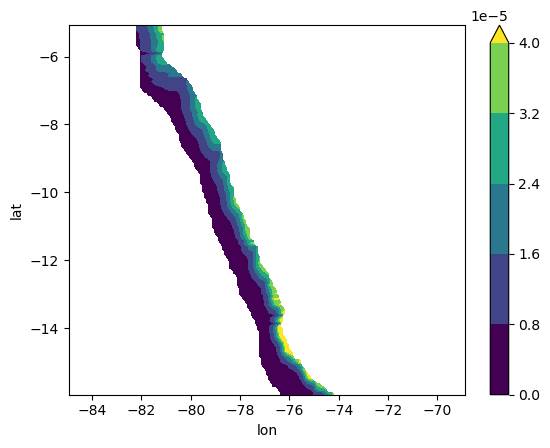

In [15]:
Wc.mean('time').plot.contourf(robust=True)

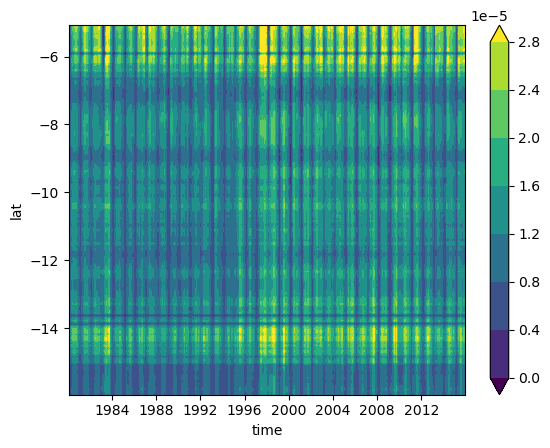

In [16]:
Wc.mean('lon').plot.contourf(x='time',robust=True)

In [17]:
Pump = (winds_c.epumping
        .mean('offshore')
        .assign_coords(lat=('coast_point', winds_c.lat.values[:, 0]))
        .swap_dims({'coast_point': 'lat'})
       .drop_vars(['coast_point', 'bearing']))
Pump

<xarray.DataArray 'epumping' (time: 432, lat: 221)> Size: 764kB
array([[-1.95717654e-07, -1.92910080e-07, -1.89567076e-07, ...,
         4.21481030e-05,  3.36477015e-05,  2.20736402e-05],
       [-1.44111496e-07, -1.45243201e-07, -1.46442830e-07, ...,
         2.93796120e-05,  2.31870277e-05,  1.48601148e-05],
       [-1.61269382e-07, -1.56685893e-07, -1.53367545e-07, ...,
         1.79561255e-05,  1.39580791e-05,  8.61995361e-06],
       ...,
       [ 1.53730104e-09, -6.25218156e-09, -1.38683546e-08, ...,
         6.83237281e-05,  5.29846551e-05,  3.07741486e-05],
       [-1.11426096e-07, -1.18068477e-07, -1.24978057e-07, ...,
         7.03775136e-05,  5.48617217e-05,  3.29262711e-05],
       [-2.26718924e-07, -2.34674697e-07, -2.44231439e-07, ...,
         5.84243020e-05,  4.56103931e-05,  2.73726911e-05]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -2.249 -2.166 -2.082

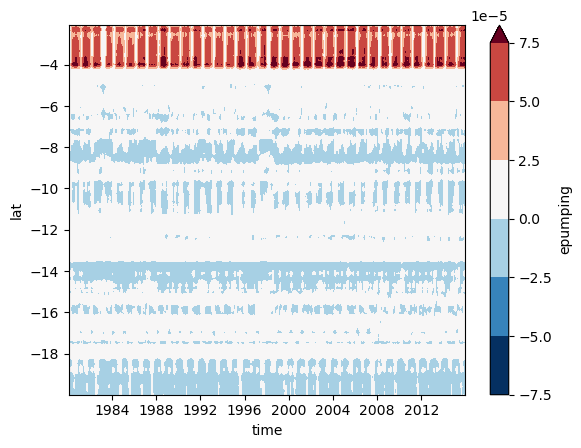

In [18]:
Pump.plot.contourf(x='time',robust=True)

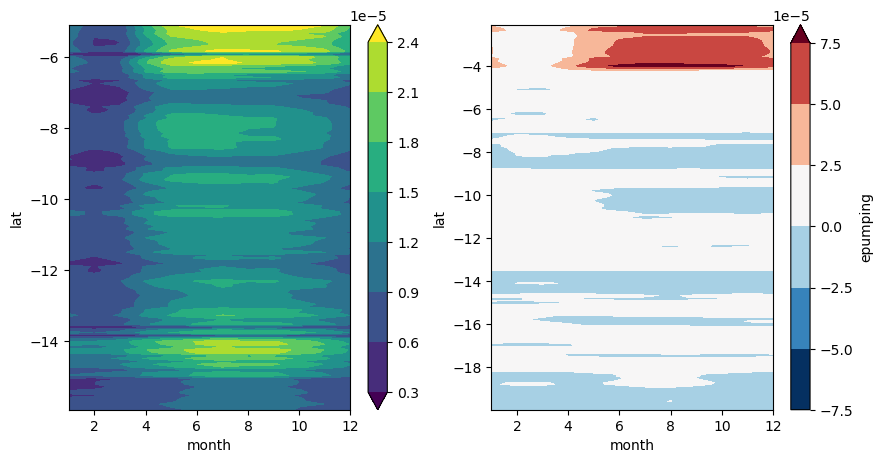

In [19]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
seasonality(Wc.mean('lon')).plot.contourf(x='month',robust=True,ax=ax[0])
seasonality(Pump).plot.contourf(x='month',robust=True,ax=ax[1])

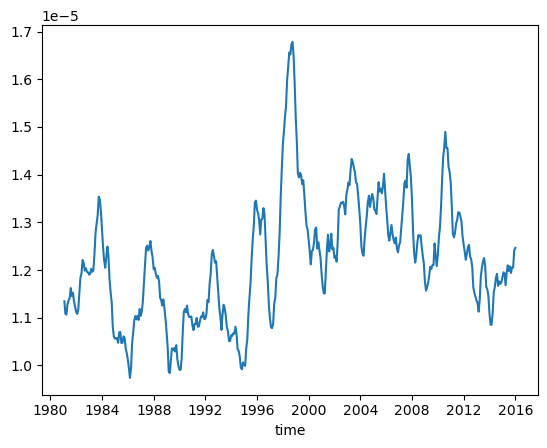

In [20]:
AV = Pump + Wc
AV.mean(dim=('lon','lat')).rolling(time=13).mean().plot()

In [21]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld, var='WMLD', iterations=10)
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

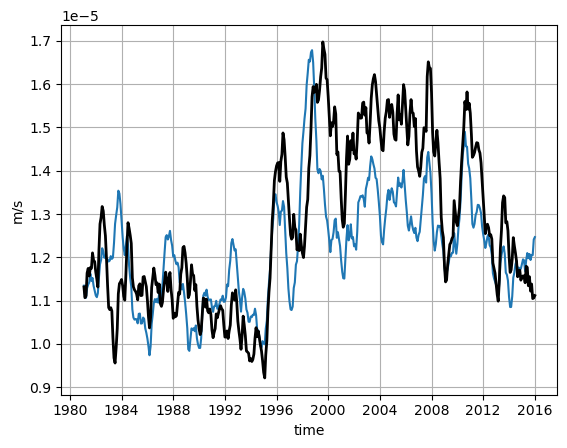

In [22]:
AV.mean(dim=('lon','lat')).rolling(time=13).mean().plot()
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

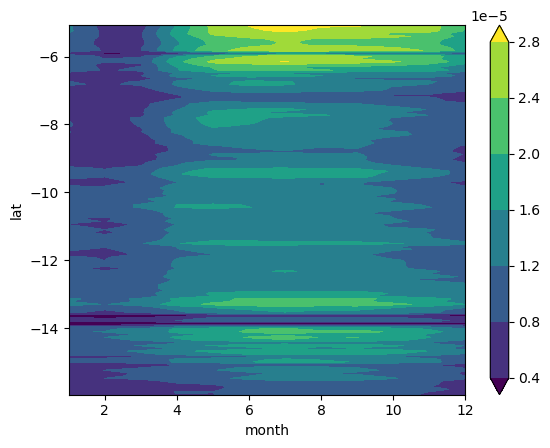

In [23]:
seasonality(AV).mean('lon').plot.contourf(x='month',robust=True)

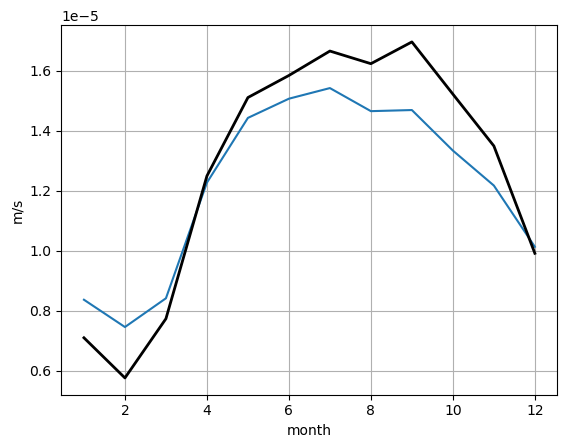

In [24]:
seasonality(AV).mean(dim=('lon','lat')).plot()
seasonality(wmld).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

* I need to correct the Ekman Pump

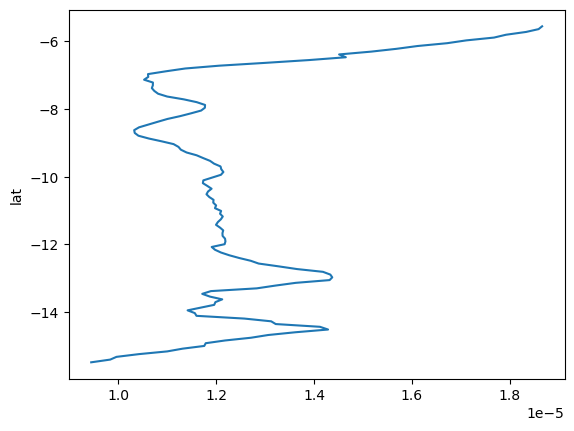

In [25]:
AV.mean(dim=('time','lon')).rolling(lat=13,center=True).mean().sel(lat=slice(-16,-5)).plot(y='lat')

## Another Ekman Pump
* Pump calculated by finite differences

In [26]:
ekpump = xr.open_dataset('Ekman_pumping.nc').compute()
ekpump

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 541, time: 432, lon: 601)
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91
Data variables:
    w_ek     (time, lat, lon) float64 1GB 2.724e-07 3.15e-07 ... nan nan

In [27]:
mask_pump = coastal_band_mask(ekpump,'w_ek',10)
ekpump=ekpump.where(mask_pump).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
ekpump

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 432, lat: 135, lon: 194)
Coordinates:
  * lat      (lat) float64 1kB -15.99 -15.91 -15.83 ... -5.2 -5.117 -5.034
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.99 -84.91 -84.83 ... -69.08 -68.99 -68.91
Data variables:
    w_ek     (time, lat, lon) float64 91MB nan nan nan nan ... nan nan nan nan

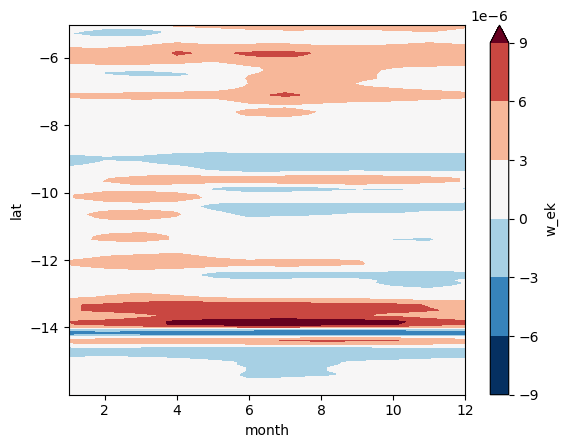

In [28]:
seasonality(ekpump.w_ek).mean('lon').plot.contourf(x='month',robust=True)

In [29]:
# Wc.lat
ekpump_centered = ((ekpump.w_ek.shift(lat=-1) + ekpump.w_ek) * 0.5).isel(lat=slice(0, -1))
# ekpump_centered = ekpump.w_ek
ekpump_centered = ekpump_centered.assign_coords(lat=Wc.lat, lon=Wc.lon)
ekpump_centered 

<xarray.DataArray 'w_ek' (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

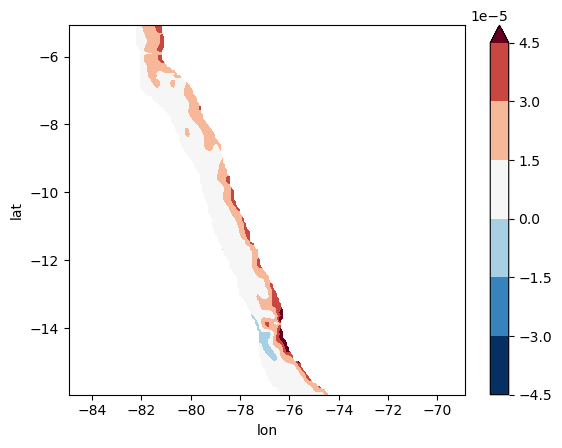

In [30]:
(ekpump_centered + Wc).mean('time').plot.contourf(robust=True)

In [31]:
AV_ = ekpump_centered + Wc
AV_

<xarray.DataArray (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

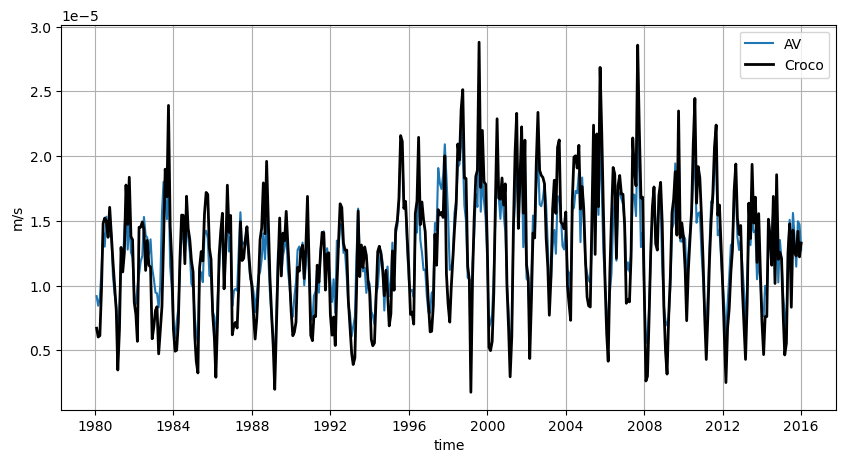

In [33]:
# AV_.mean(dim=('lon','lat')).AV.plot(figsize=(10,5),label='AV')
AV_.mean(dim=('lon','lat')).plot(figsize=(10,5),label='AV')
wmld.mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)
plt.legend()

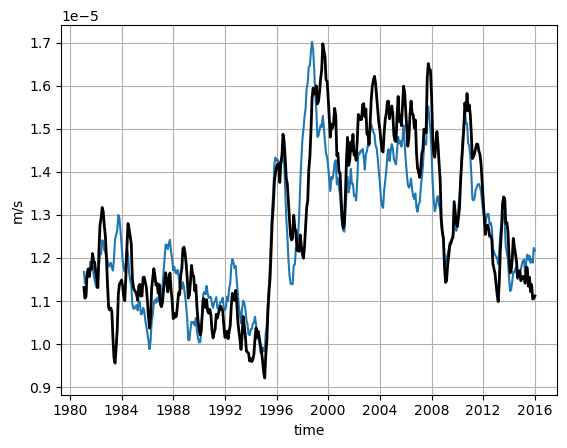

In [34]:
AV_.mean(dim=('lon','lat')).rolling(time=13).mean().plot()
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

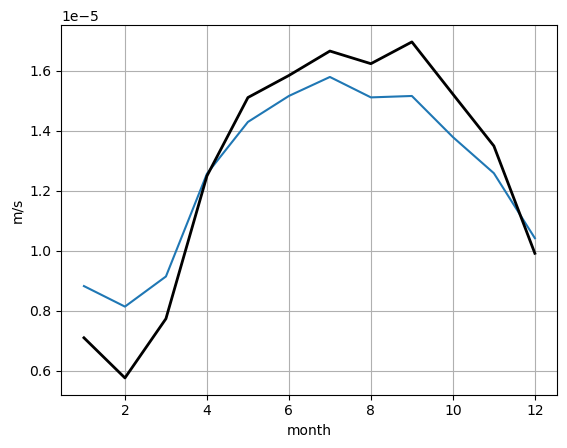

In [35]:
seasonality(AV_).mean(dim=('lon','lat')).plot()
seasonality(wmld).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

In [36]:
AV_ = AV_.to_dataset(name='AV')
AV_

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
Data variables:
    AV       (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

In [37]:
AV_['Epumping'] = ekpump_centered
AV_['Wc'] = Wc

In [ ]:
# AV_.to_netcdf('latitudinal/AV.nc')